In [1]:
from __future__ import division
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
from scipy import stats
import scipy.spatial as spa
%matplotlib inline

In [2]:
generation_list = []

for i in range(10002):
    generation_list.append(i)
    
print(len(generation_list))

10002


In [3]:
def get_data1(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_var_mean = []
    total_var_std = []
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        var_mean = []
        var_std = []
       
        fit_mean.extend(list(pd.Series(f.mFit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.mFit_Std,dtype=float)))
    
        var_mean.extend(list(pd.Series(f.varFit_Mean,dtype=float)))
        var_std.extend(list(pd.Series(f.varFit_Std,dtype=float)))
    
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_var_mean.append(var_mean)
        total_var_std.append(var_std)  
        
    return total_fit_mean, total_fit_std, total_var_mean, total_var_std

In [4]:
def get_data2(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_var_mean = []
    total_var_std = []
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        var_mean = []
        var_std = []
       
        fit_mean.extend(list(pd.Series(f.meanFit,dtype=float)))
        fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    
        var_mean.extend(list(pd.Series(f.PopVar_Mean,dtype=float)))
        var_std.extend(list(pd.Series(f.PopVar_STD,dtype=float)))
    
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_var_mean.append(var_mean)
        total_var_std.append(var_std)  
        
    return total_fit_mean, total_fit_std, total_var_mean, total_var_std

In [5]:
def read_file(data):
    with open(data, 'rb') as f:
        x = pickle.load(f)
        
    return x

In [6]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 36})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(6)
    ax.spines['bottom'].set_linewidth(6)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=6, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=6, direction='out', pad=50, colors='black')

## P = 128_N =500_Rep =100_10KG

### Adaptation

In [22]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181220_Test of FGM_5_Monitor Amito Load\Data\4.1C. NP_P = 128_Rep = 100_10KG\Adaptation")

In [23]:
ad_list = ['NP_Dim10_P128_Amito_N500_Fit05_SM005_10KG_Rep100_191124.csv']

In [24]:
ad = get_data1(ad_list)

ad_fit_mean =ad[0][0]
ad_fit_std = ad[1][0]

In [25]:
ad_fit_mean[-1]

0.79364249415369759

In [26]:
ad_fit_std[-1]

0.040721246628618625

In [27]:
ad_fit_mean[-1]-1.98*ad_fit_std[-1]/10

0.78557968732123107

In [28]:
ad_fit_mean[-1]+1.98*ad_fit_std[-1]/10

0.8017053009861641

#### Check equilibrium of last certain generation

In [29]:
fit_file = ['NP_Dim10_P128_Amito_N500_Fit05_SM005_10KG_Pop_MFit_Rep100_191124']

total_fit = []

for i in fit_file:
    total_fit.append(read_file(i))

In [65]:
total_fit= np.array(total_fit)

In [68]:
total_fit.shape

(1L, 100L, 10002L)

In [33]:
def get_slope(mu_file, generation):
    
    slope = []
    data = mu_file[:, -generation:]
    
    x = np.arange(len(data[0]))
    
    for i in range(len(data)):
        slope.append(stats.linregress(x, data[i])[0])
    
    return slope

In [87]:
fit_slope_500 = []

for i in range(len(total_fit)):
    fit_slope_500.append(get_slope(total_fit[i], 500))

In [74]:
fit_slope_1k = []

for i in range(len(total_fit)):
    fit_slope_1k.append(get_slope(total_fit[i], 1000))

In [78]:
fit_slope_2k = []

for i in range(len(total_fit)):
    fit_slope_2k.append(get_slope(total_fit[i], 2000))

In [34]:
def bootstrap(analyze_list, repeat_times):
    
    n = len(analyze_list)
    
    total_selected_index = []
    total_mean_sample = []
    
    for i in range(repeat_times):
        selected_index= []
        while len(selected_index)<n:
            selected_index.append(np.random.randint(0, n))
        
        selected_sample = [analyze_list[j] for j in selected_index]
        
        mean_selected_sample = np.nanmean(selected_sample)
        

        total_selected_index.append(selected_index)
        total_mean_sample.append(mean_selected_sample)
        
    
    final_mean = np.nanmean(total_mean_sample)
    
    total_mean_sample = np.array(total_mean_sample)
    
    final_lower = np.percentile(total_mean_sample, 2.5)
    final_upper = np.percentile(total_mean_sample, 97.5)
    
    
    confidence_range = [final_lower, final_upper]
    
    return final_mean, final_lower, final_upper, confidence_range

In [35]:
def check_equilibrium(file_list):

    total_mean = []
    total_lower = []
    total_upper = []
    total_crange = []

    for x in file_list:
        bs = bootstrap(x, 10000)
        total_mean.append(bs[0])
        total_lower.append(bs[1])
        total_upper.append(bs[2])
        total_crange.append(bs[3])

    print 'TOTAL MEAN', total_mean
    print 'TOTAL LOWER', total_lower
    print 'TOTAL UPPER', total_upper
    print 'TOTAL CONFIDENCE RANGE', total_crange

    return total_mean, total_lower, total_upper, total_crange

In [88]:
fit_500_equ = check_equilibrium(fit_slope_500)

fit_500_mean = fit_500_equ[0]
fit_500_lower = fit_500_equ[1]
fit_500_upper = fit_500_equ[2]
fit_500_crange = fit_500_equ[3]

TOTAL MEAN [1.3115766792959345e-06]
TOTAL LOWER [-2.1365017016793894e-06]
TOTAL UPPER [5.0573642721699606e-06]
TOTAL CONFIDENCE RANGE [[-2.1365017016793894e-06, 5.0573642721699606e-06]]


In [81]:
fit_1k_equ = check_equilibrium(fit_slope_1k)

fit_1k_mean = fit_1k_equ[0]
fit_1k_lower = fit_1k_equ[1]
fit_1k_upper = fit_1k_equ[2]
fit_1k_crange = fit_1k_equ[3]

TOTAL MEAN [9.9473005337348186e-07]
TOTAL LOWER [-1.2854083714237049e-06]
TOTAL UPPER [3.3161091426689534e-06]
TOTAL CONFIDENCE RANGE [[-1.2854083714237049e-06, 3.3161091426689534e-06]]


In [82]:
fit_2k_equ = check_equilibrium(fit_slope_2k)

fit_2k_mean = fit_2k_equ[0]
fit_2k_lower = fit_2k_equ[1]
fit_2k_upper = fit_2k_equ[2]
fit_2k_crange = fit_2k_equ[3]

TOTAL MEAN [4.4407673005260027e-06]
TOTAL LOWER [2.6149076663146476e-06]
TOTAL UPPER [6.4437949930816523e-06]
TOTAL CONFIDENCE RANGE [[2.6149076663146476e-06, 6.4437949930816523e-06]]


In [89]:
slope_mean = fit_500_mean + fit_1k_mean + fit_2k_mean
slope_lower = fit_500_lower + fit_1k_lower + fit_2k_lower
slope_upper = fit_500_upper + fit_1k_upper + fit_2k_upper

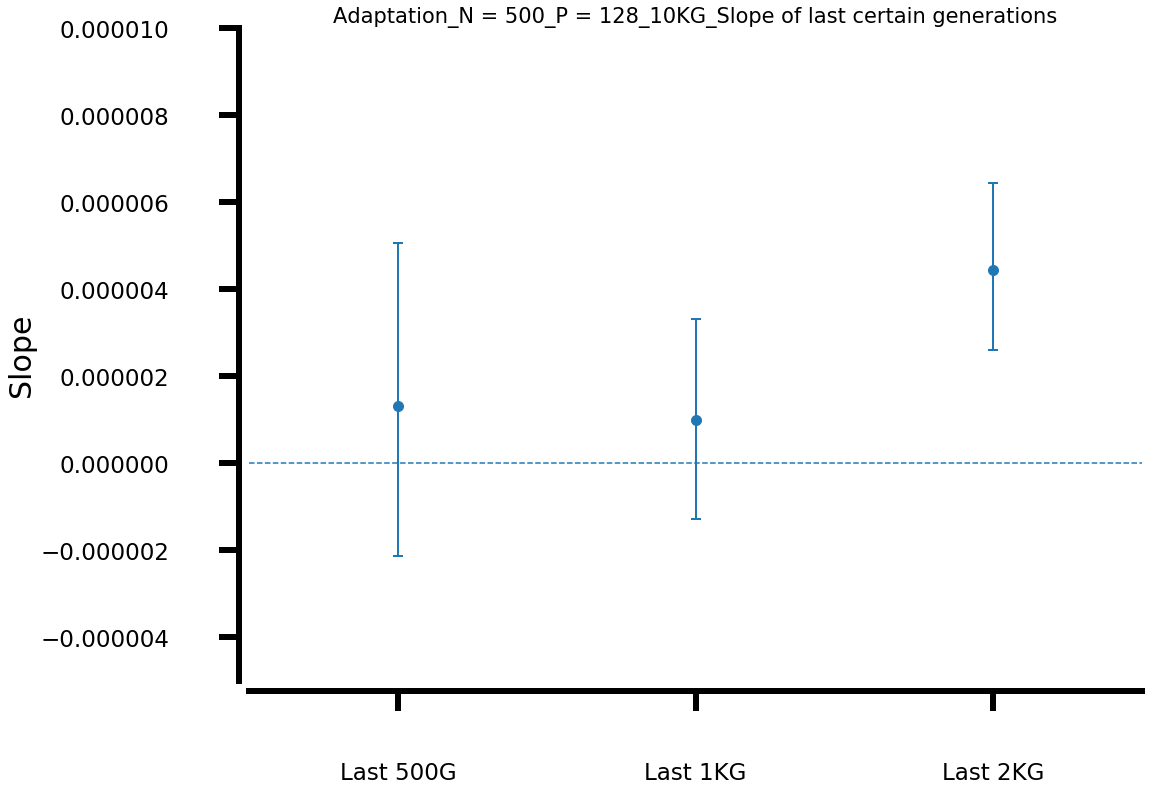

In [95]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)

mean = slope_mean
lower_error = list(np.array(slope_mean) -np.array(slope_lower))
upper_error = list(np.array(slope_upper) -np.array(slope_mean))


plt.errorbar( xrange(3), mean, yerr=[lower_error, upper_error], fmt='o', markersize =10, lw=2, capsize=5, capthick=2)


plt.title('Adaptation_N = 500_P = 128_10KG_Slope of last certain generations', fontsize =21)
plt.ylabel('Slope', fontsize =30)
plt.axhline(y=0, xmin=0, xmax=22, ls ='dashed')

ax = plt.subplot(111)
# ax.axhline(y =-0.00005, linewidth=8, color ='black')       
# ax.axvline(x  =-1, linewidth=8, color = 'black')   

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

x = range(3)
my_xticks = ['Last 500G', 'Last 1KG', 'Last 2KG']
plt.xticks(x, my_xticks, rotation =0)

plt.tick_params(axis='both', labelsize=23)

plt.xlim(-0.5, 2.5)
plt.ylim(-0.000005, 0.00001)


plt.show()

### Amitosis load

In [11]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181220_Test of FGM_5_Monitor Amito Load\Data\4.1C. NP_P = 128_Rep = 100_10KG\Load")

In [12]:
al_list = ['Cor_AmitoLoad_NoPley_P128_N500_Dim10_IF1_MutScale0005199_10KG_100Rep.csv']

In [13]:
al = get_data1(al_list)

al_fit_mean =al[0][0]
al_fit_std = al[1][0]

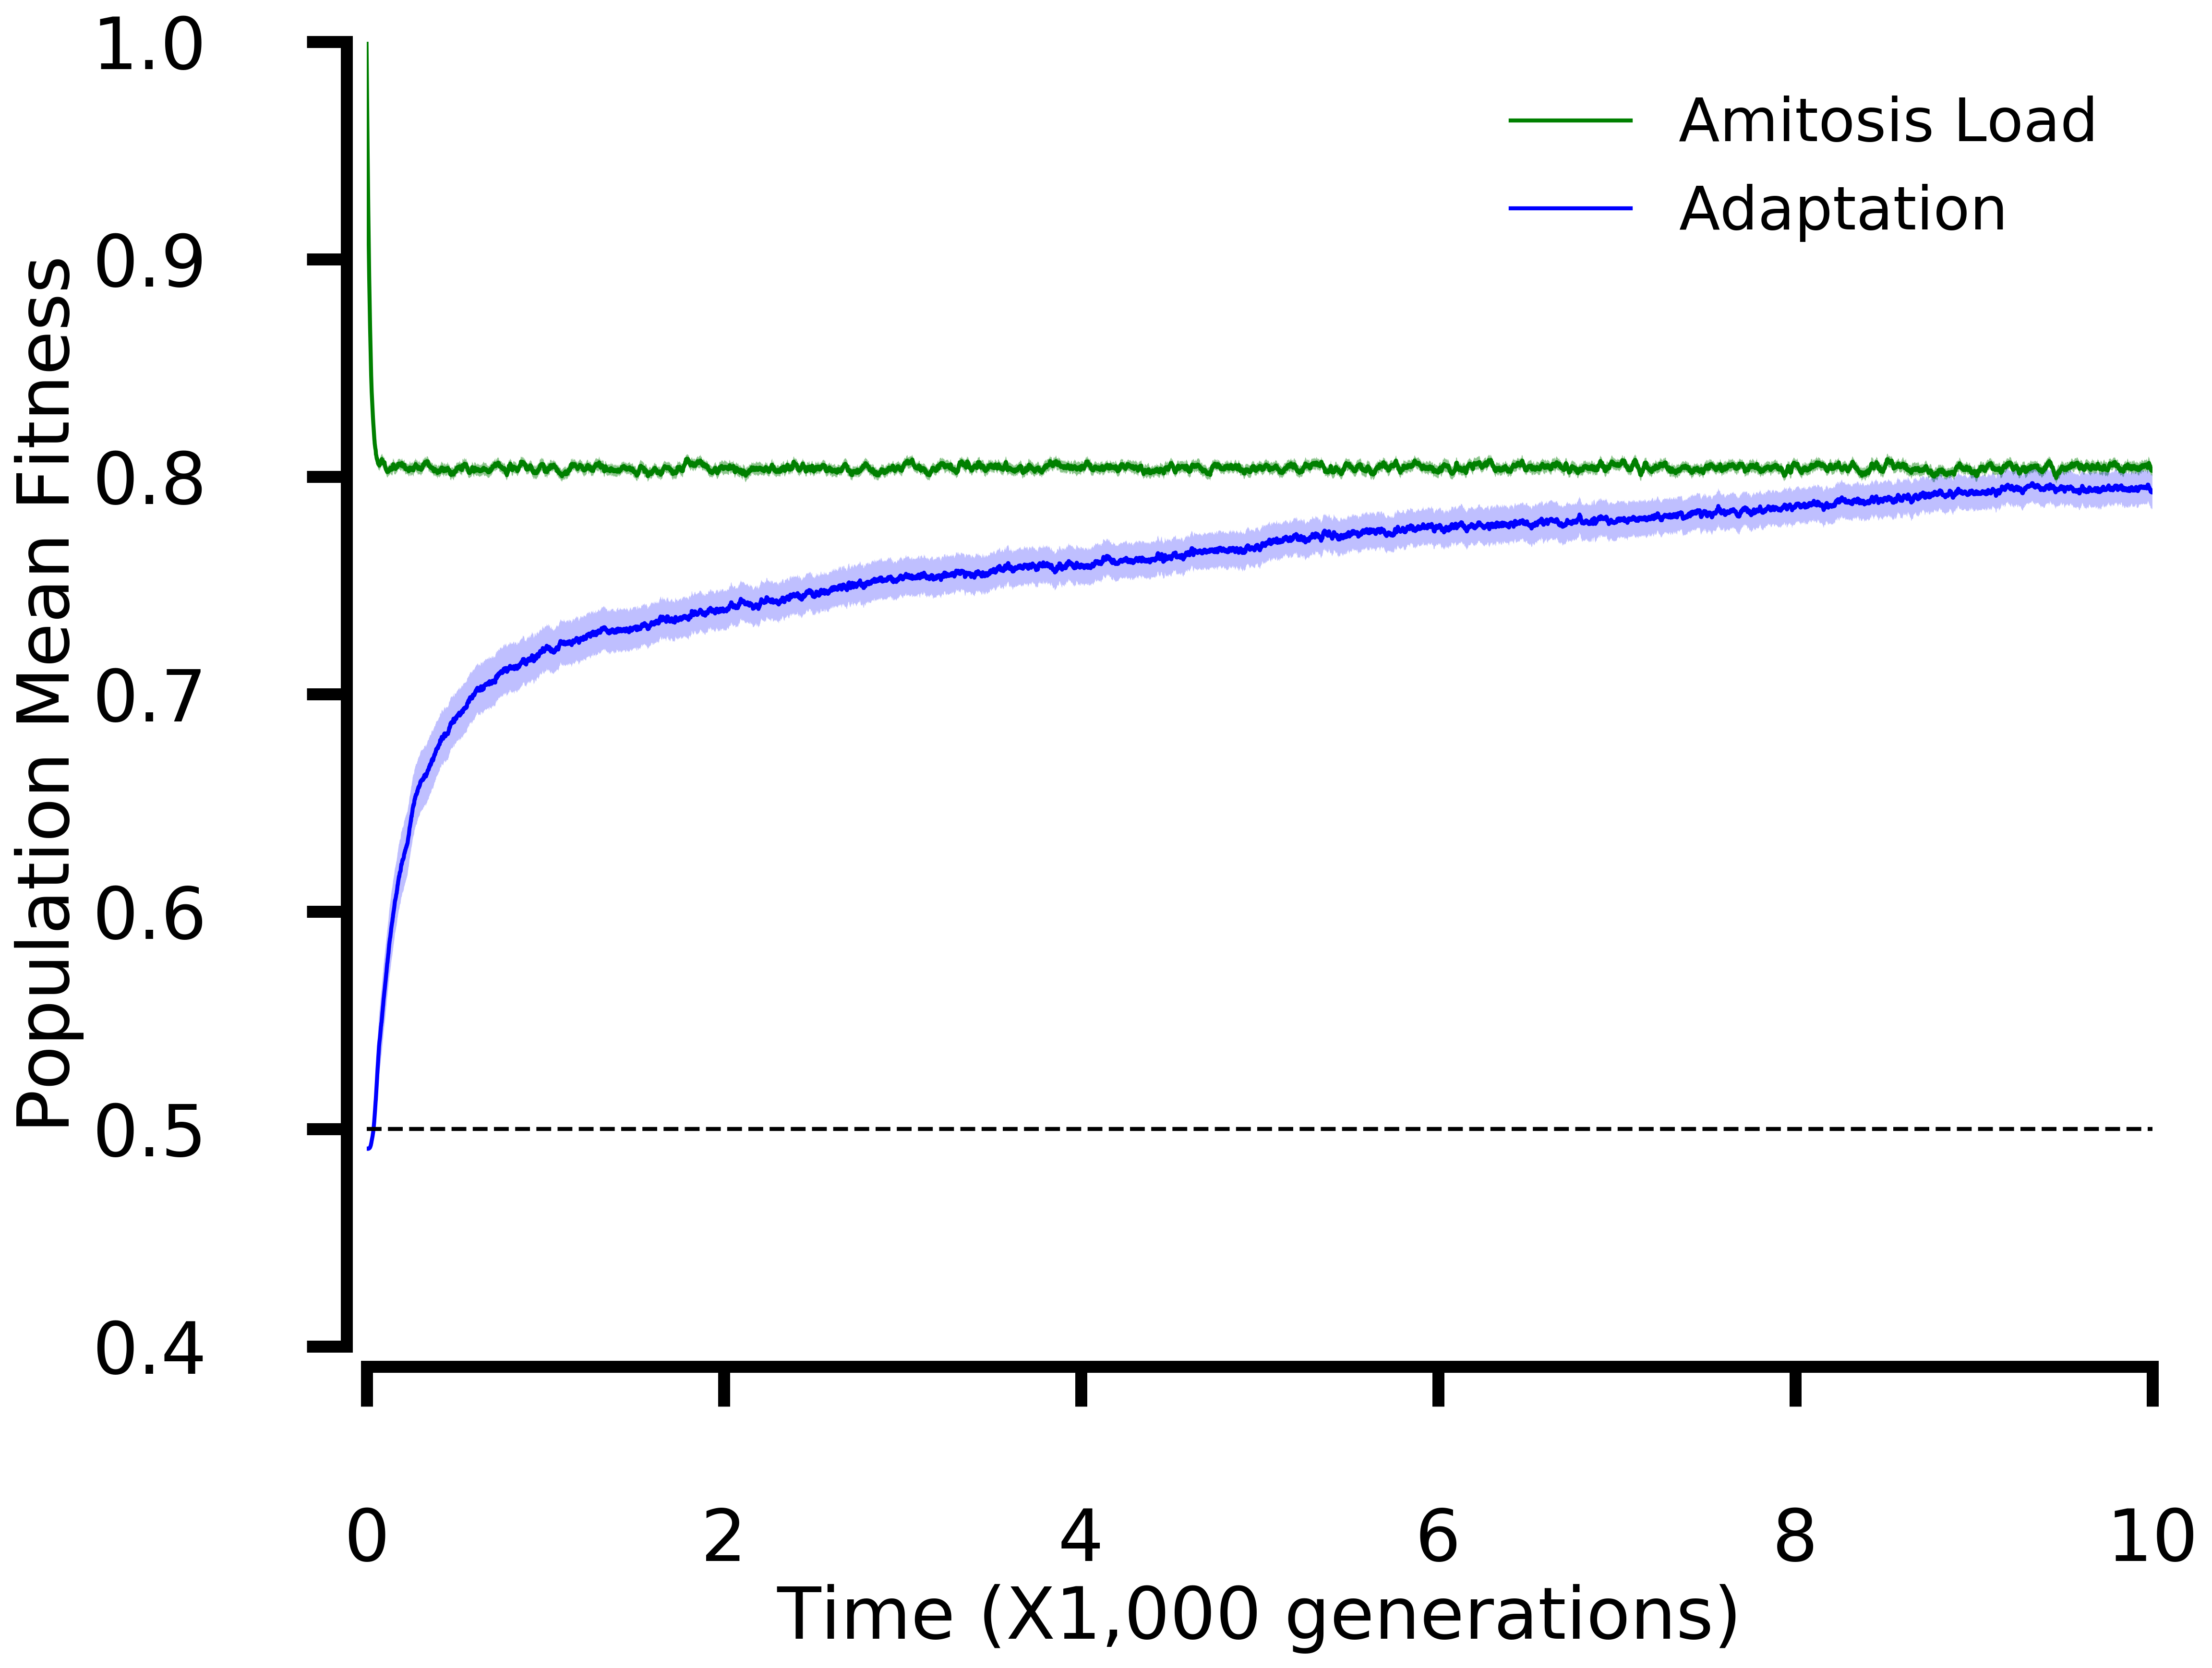

In [14]:
fig = plt.figure(figsize=(16, 12), dpi =300)
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,10000)

t = generation_list

a = al_fit_mean
error_a = list(1.98* np.array(al_fit_std)/((100)**0.5))

b = ad_fit_mean
error_b = list(1.98* np.array(ad_fit_std)/((100)**0.5))


# ax.set_title('FGM_No Pley_Adapt Vs Amito Load_P =128_N =500_Rep =500_Corrected', fontsize =35)
ax.set_xlabel('Time (X1,000 generations)', fontsize =36)
ax.set_ylabel('Population Mean Fitness', fontsize =36)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a,'g', label = 'Amitosis Load',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.45, facecolor='g')

ax.plot(t,b,'b', label = 'Adaptation', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.25, facecolor='b')



plt.axhline(y=0.5, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

# legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
# frame = legend.get_frame()
# # frame.set_framecolor('black')
# frame.set_edgecolor('black')

# extraticks=[0.45, 0.95]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(0.4, 1)

plt.legend(loc='upper right', frameon=False, prop={'size':30})


plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))
plt.show()

### Mutation load

In [11]:
"""
This set of data is used to explain the fitness discrepancy between amitosis load and adapting population.

We thought that this is caused by the adapting population also suffers mutation load (as mutation process occurred 
in the adapting population while amitosis load population didn’t)

To quantify the mutation load, we start a mitotic population sitting in the optimum and having mutation process 
same as the adapting amitosis population. Once this mitotic population reaches equilibrium, then the fitness loss 
is the mutation load.

"""

'\nThis set of data is used to explain the fitness discrepancy between amitosis load and adapting population.\n\nWe thought that this is caused by the adapting population also suffers mutation load (as mutation process occurred \nin the adapting population while amitosis load population didn\xe2\x80\x99t)\n\nTo quantify the mutation load, we start a mitotic population sitting in the optimum and having mutation process \nsame as the adapting amitosis population. Once this mitotic population reaches equilibrium, then the fitness loss \nis the mutation load.\n\n'

In [30]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181220_Test of FGM_5_Monitor Amito Load\Data\4.1C. NP_P = 128_Rep = 100_10KG\Mutation Load")

In [13]:
ml_list = ['NP_Dim10_P128_Mito_N500_Fit1_SM005_10KG_Rep100_MutLoad_200309.csv']

In [14]:
ml = get_data1(ml_list)

ml_fit_mean =ml[0][0]
ml_fit_std = ml[1][0]

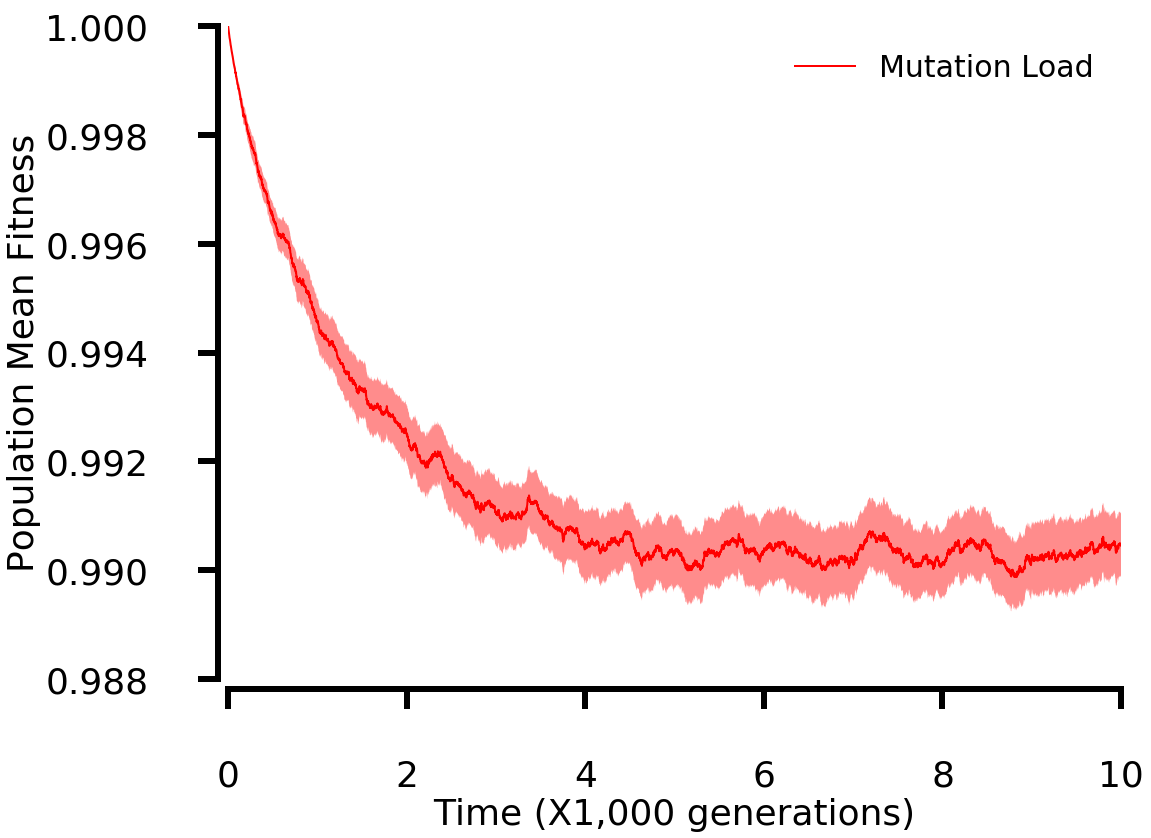

In [19]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,10000)

t = generation_list

a = ml_fit_mean
error_a = list(1.98* np.array(ml_fit_std)/((100)**0.5))


# ax.set_title('FGM_No Pley_Adapt Vs Amito Load_P =128_N =500_Rep =500_Corrected', fontsize =35)
ax.set_xlabel('Time (X1,000 generations)', fontsize =36)
ax.set_ylabel('Population Mean Fitness', fontsize =36)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a,'r', label = 'Mutation Load',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.45, facecolor='r')


plt.axhline(y=0.5, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

# legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
# frame = legend.get_frame()
# # frame.set_framecolor('black')
# frame.set_edgecolor('black')

# extraticks=[0.45, 0.95]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(0.988, 1)

plt.legend(loc='upper right', frameon=False, prop={'size':30})


plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))
plt.show()

In [20]:
print np.array(a)[-1]- np.array(error_a)[-1]
print np.array(a)[-1]+ np.array(error_a)[-1]

0.989871059092
0.99103035261


In [50]:
print 1-np.array(a)[-1]
print 1-(np.array(a)[-1]- np.array(error_a)[-1])
print 1-(np.array(a)[-1]+ np.array(error_a)[-1])

0.00954929414893
0.010128940908
0.00896964738985


In [31]:
ml_fit_file = ['NP_Dim10_P128_Mito_N500_Fit1_SM005_10KG_Pop_MFit_Rep100_MutLoad_200309']

total_ml_fit = []

for i in ml_fit_file:
    total_ml_fit.append(read_file(i))

In [38]:
total_ml_fit= np.array(total_ml_fit)

In [39]:
ml_fit_slope_500 = []

for i in range(len(total_ml_fit)):
    ml_fit_slope_500.append(get_slope(total_ml_fit[i], 500))

In [40]:
ml_fit_slope_1k = []

for i in range(len(total_ml_fit)):
    ml_fit_slope_1k.append(get_slope(total_ml_fit[i], 1000))

In [41]:
ml_fit_slope_2k = []

for i in range(len(total_ml_fit)):
    ml_fit_slope_2k.append(get_slope(total_ml_fit[i], 2000))

In [42]:
ml_fit_500_equ = check_equilibrium(ml_fit_slope_500)

ml_fit_500_mean = ml_fit_500_equ[0]
ml_fit_500_lower = ml_fit_500_equ[1]
ml_fit_500_upper = ml_fit_500_equ[2]
ml_fit_500_crange = ml_fit_500_equ[3]

TOTAL MEAN [3.0955405613078126e-07]
TOTAL LOWER [-7.9292935048519065e-07]
TOTAL UPPER [1.3951217187255909e-06]
TOTAL CONFIDENCE RANGE [[-7.9292935048519065e-07, 1.3951217187255909e-06]]


In [43]:
ml_fit_1k_equ = check_equilibrium(ml_fit_slope_1k)

ml_fit_1k_mean = ml_fit_1k_equ[0]
ml_fit_1k_lower = ml_fit_1k_equ[1]
ml_fit_1k_upper = ml_fit_1k_equ[2]
ml_fit_1k_crange = ml_fit_1k_equ[3]

TOTAL MEAN [2.9288134948364283e-07]
TOTAL LOWER [-4.650417327147215e-07]
TOTAL UPPER [1.1000274893631621e-06]
TOTAL CONFIDENCE RANGE [[-4.650417327147215e-07, 1.1000274893631621e-06]]


In [44]:
ml_fit_2k_equ = check_equilibrium(ml_fit_slope_2k)

ml_fit_2k_mean = ml_fit_2k_equ[0]
ml_fit_2k_lower = ml_fit_2k_equ[1]
ml_fit_2k_upper = ml_fit_2k_equ[2]
ml_fit_2k_crange = ml_fit_2k_equ[3]

TOTAL MEAN [2.6862321032573485e-08]
TOTAL LOWER [-3.8370878649529164e-07]
TOTAL UPPER [4.3812327497185964e-07]
TOTAL CONFIDENCE RANGE [[-3.8370878649529164e-07, 4.3812327497185964e-07]]


In [45]:
ml_slope_mean = ml_fit_500_mean + ml_fit_1k_mean + ml_fit_2k_mean
ml_slope_lower = ml_fit_500_lower + ml_fit_1k_lower + ml_fit_2k_lower
ml_slope_upper = ml_fit_500_upper + ml_fit_1k_upper + ml_fit_2k_upper

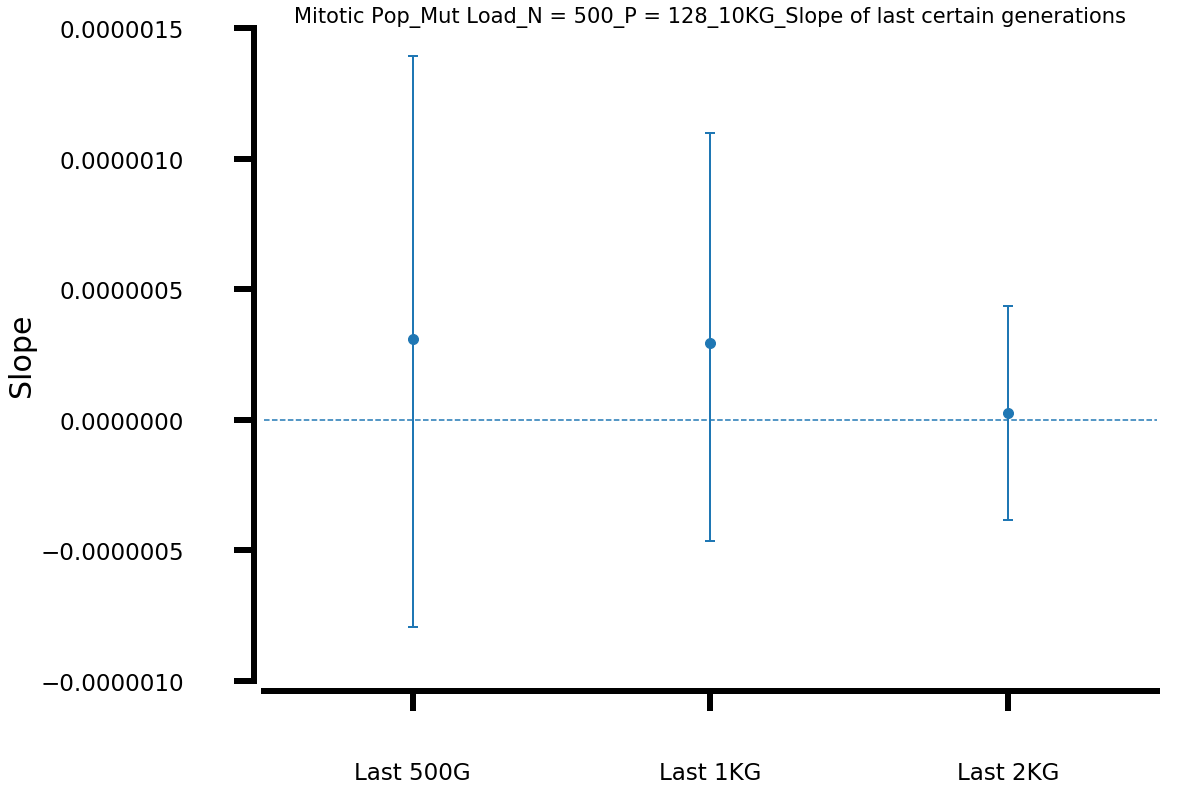

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)

mean = ml_slope_mean
lower_error = list(np.array(ml_slope_mean) -np.array(ml_slope_lower))
upper_error = list(np.array(ml_slope_upper) -np.array(ml_slope_mean))


plt.errorbar( xrange(3), mean, yerr=[lower_error, upper_error], fmt='o', markersize =10, lw=2, capsize=5, capthick=2)


plt.title('Mitotic Pop_Mut Load_N = 500_P = 128_10KG_Slope of last certain generations', fontsize =21)
plt.ylabel('Slope', fontsize =30)
plt.axhline(y=0, xmin=0, xmax=22, ls ='dashed')

ax = plt.subplot(111)
# ax.axhline(y =-0.00005, linewidth=8, color ='black')       
# ax.axvline(x  =-1, linewidth=8, color = 'black')   

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

x = range(3)
my_xticks = ['Last 500G', 'Last 1KG', 'Last 2KG']
plt.xticks(x, my_xticks, rotation =0)

plt.tick_params(axis='both', labelsize=23)

plt.xlim(-0.5, 2.5)
plt.ylim(-0.000001, 0.0000015)


plt.show()